In [3]:
import time
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload

import BasicModules_source.nudec_v2
# if NuDec source file has been modified it needs to be reloaded
nudec_source = reload(BasicModules_source.nudec_v2)

In [4]:
"""
Call NuDec class constructer (instantiation) 
"""

start_time  = time.time()
nudec       = nudec_source.NuDec()
end_time    = time.time()
print("")
print("instantiation time:", f"{(end_time - start_time):.2g}", "[s]")

Finished constructing interpolation functions.                 
instantiation time: 0.72 [s]


In [5]:
"""
Solve neutrino decoupling evolution

mode: 
1: no osc, mu=0; 
2: no osc, mu!=0; 
3: osc, mu=0; 
4: osc, mu!=0

order:
0, 1 = O(e^0) 
2 = O(e^2)
3 = O(e^3)
4 = O(e^4)
5 = O(e^5)
6 = O(e^5+log term)
"""

start_time = time.time()
[t, y]     = nudec.evolve(mode=2,order=3)
# output: numpy array: y = [T_gam, T_nue, T_numu, mu_nue, mu_numu, z]
end_time = time.time()
print("\nsolver time:", f"{(end_time - start_time):.3g}", "[s]")


 solve system from T_ini = 10.000 to T_fin = 0.009 [MeV]
 --> t_ini = 7.39E-03 [s] to t_fin = 1.63E+04 [s]

Progress: 100.000 %
solver time: 2.09 [s]


In [6]:
neff        = nudec.Neff(T_gam= y[0][-1], T_nue= y[1][-1], T_numu= y[2][-1], mu_nue= y[3][-1], mu_numu= y[4][-1])
gstar_rho   = nudec.gstar_rho(T_gam= y[0][-1], T_nue= y[1][-1], T_numu= y[2][-1], mu_nue= y[3][-1], mu_numu= y[4][-1])
gstar_s     = nudec.gstar_s(T_gam= y[0][-1], T_nue= y[1][-1], T_numu= y[2][-1], mu_nue= y[3][-1], mu_numu= y[4][-1])
m_over_Omega= nudec.m_over_Omega(T_gam= y[0][-1], T_nue= y[1][-1], T_numu= y[2][-1], mu_nue= y[3][-1], mu_numu= y[4][-1])
heff        = nudec.heff(y[5][-1])


print("Neff         = ", f"{neff:.7}")
print("gstar_rho    = ", f"{gstar_rho:.7g}")
print("gstar_s      = ", f"{gstar_s:.7g}")
print("heff         = ", f"{heff:.7g}")
print("m_over_Omega = ", f"{m_over_Omega:.7g}")



print(" --- ")
print("percentage deviation to fortepiano")
print(f"{100*(1 - neff/3.0439):.3g}", "%")
print(f"{100*(1 - gstar_rho/3.3826):.3g}", "%")
print(f"{100*(1 - gstar_s/3.9302):.3g}", "%")
print(f"{100*(1 - heff/3.9298 ):.3g}", "%")
print(f"{100*(1 - m_over_Omega/93.119):.3g}", "%")

Neff         =  3.043658
gstar_rho    =  3.382474
gstar_s      =  3.929888
heff         =  3.929785
m_over_Omega =  93.12702
 --- 
percentage deviation to fortepiano
0.00797 %
0.00373 %
0.00795 %
0.000391 %
-0.00862 %


# Collection of Plots

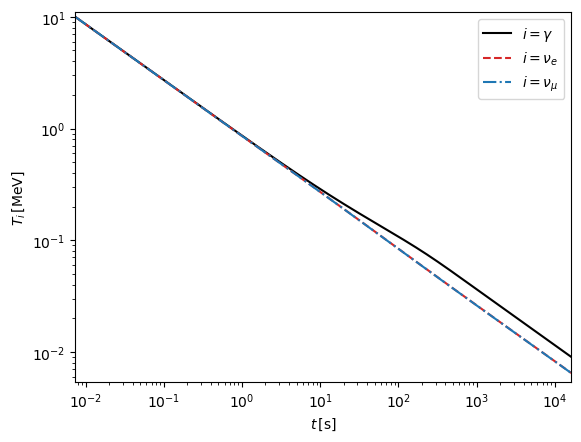

In [7]:
# Plot the time evolution of QED and neutrino temperatures
# this is a direct output of nudec_source.NuDec().evolve(). Here the results has been stored in the arrays [t, y]

plt1, = plt.loglog(t, y[0], lw= 1.5, color= 'k', label= r'$i = \gamma$')
plt2, = plt.loglog(t, y[1], lw= 1.5, color= 'tab:red', ls='--', label= r'$i = \nu_e$')
plt3, = plt.loglog(t, y[2], lw= 1.5, color= 'tab:blue', ls='-.', label= r'$i = \nu_\mu$')

plt.legend(handles=[plt1, plt2, plt3])

plt.ylabel(r'$T_i\,[\mathrm{MeV}]$')
plt.xlabel(r'$t\,[\mathrm{s}]$')
plt.ylim(y[1][-1]/1.2, y[1][0]*1.1)
plt.xlim([t[0],t[-1]])
plt.show()

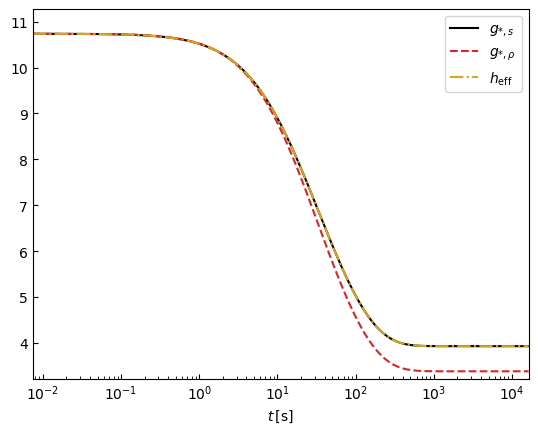

In [8]:
# Plot the evolution of different observables, here selected 1) g_*s, 2) g_*rho and 3) h_eff
# Observables can be obtained with the solution of the neutrino decoupling evolution

fig, ax = plt.subplots()
ax.tick_params(direction='in')
ax.tick_params(which='minor', direction='in')

arr_gstars      = np.array([nudec.gstar_s(T_gam= y[0][i], T_nue= y[1][i], T_numu= y[2][i], mu_nue= y[3][i], mu_numu= y[4][i]) for i in range(len(y[0]))])
arr_gstarrho    = np.array([nudec.gstar_rho(T_gam= y[0][i], T_nue= y[1][i], T_numu= y[2][i], mu_nue= y[3][i], mu_numu= y[4][i]) for i in range(len(y[0]))])
arr_heff        = np.array([nudec.heff(z= y[5][i]) for i in range(len(y[5]))])


plt1,= plt.semilogx(t, arr_gstars, lw= 1.5, color= 'k', label= r'$g_{*,s}$')
plt2,= plt.semilogx(t, arr_gstarrho, lw= 1.5, color= 'tab:red', ls='--', label= r'$g_{*,\rho}$')
plt3,= plt.semilogx(t, arr_heff, lw= 1.5, color='goldenrod', ls= '-.', label= r'$h_{\mathrm{eff}}$')


plt.legend(handles=[plt1, plt2, plt3])


plt.xlabel(r'$t\,[\mathrm{s}]$')

plt.ylim([arr_gstarrho[-1]/1.05, arr_gstarrho[0]*1.05])
plt.xlim([t[0],t[-1]])

plt.show()

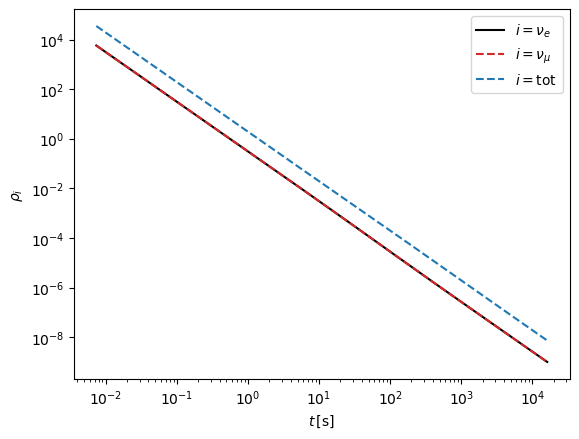

In [9]:
# Plot the evolution of the energy density of neutrinos and the total QED+neutrino ensemble
# Thermodynamical quantities like the energy density, number density, pressure etc. can be accessed by nudec.thermo.XYZ()


arr_rho_nue     = [nudec.thermo.Rho_FD(T= y[1][i], mu= y[3][i]) for i in range(len(t))]
arr_rho_numu    = [nudec.thermo.Rho_FD(T= y[2][i], mu= y[4][i]) for i in range(len(t))]
arr_rho_tot     = [nudec.thermo.Rho_tot(T_gam= y[0][i], T_nue= y[1][i], T_numu= y[2][i], mu_nue= y[3][i], mu_numu= y[4][i]) for i in range(len(t))]


plt1,= plt.loglog(t, arr_rho_nue, lw= 1.5, color= 'k', label= r'$i = \nu_e$')
plt2,= plt.loglog(t, arr_rho_numu, lw= 1.5, color= 'tab:red', ls='--', label= r'$i = \nu_\mu$')
plt3,= plt.loglog(t, arr_rho_tot, lw= 1.5, color= 'tab:blue', ls='--', label= r'$i = \mathrm{tot}$')


plt.legend(handles=[plt1, plt2, plt3])

plt.ylabel(r'$\rho_i$')
plt.xlabel(r'$t\,[\mathrm{s}]$')

plt.show()